In [1]:
import random
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import csv
import scipy
from tqdm import tqdm
import os
cd = os.getcwd()
import pickle
set_device("cpp_standalone", build_on_run=False, directory="standalone_project")
#print("Active device:", device.get_device().name)  # should print cpp_standalone

In [2]:
def sim(trial,gamma, epsilon, g, nu_ext_over_nu_thr, sim_time):
    """
    g -- relative inhibitory to excitatory synaptic strength
    nu_ext_over_nu_thr -- ratio of external stimulus rate to threshold rate
    sim_time -- simulation time
    """

    # network parameters
    N_E = 5000
    gamma = gamma
    N_I = round(gamma * N_E)
    N = N_E + N_I
    epsilon = epsilon
    C_E = epsilon * N_E
    C_ext = C_E

    #recording
    N_E_rec = int(50/(1+gamma))
    N_I_rec = 50 - N_E_rec

    # neuron parameters
    tau = 20 * ms
    theta = 20 * mV
    V_r = 10 * mV
    tau_rp = 2 * ms

    # synapse parameters
    J = 0.1 * mV
    D = 1.5 * ms

    # external stimulus
    nu_thr = theta / (J * C_E * tau)

    defaultclock.dt = 0.1 * ms

    neurons = NeuronGroup(N,
                          """
                          dv/dt = -v/tau : volt (unless refractory)
                          """,
                          threshold="v > theta",
                          reset="v = V_r",
                          refractory=tau_rp,
                          method="exact",
    )

    excitatory_neurons = neurons[:N_E]
    inhibitory_neurons = neurons[N_E:]

    exc_synapses = Synapses(excitatory_neurons, target=neurons, on_pre="v += J", delay=D)
    exc_synapses.connect(p=epsilon)

    inhib_synapses = Synapses(inhibitory_neurons, target=neurons, on_pre="v += -g*J", delay=D)
    inhib_synapses.connect(p=epsilon)

    nu_ext = nu_ext_over_nu_thr * nu_thr

    external_poisson_input = PoissonInput(
        target=neurons, target_var="v", N=C_ext, rate=nu_ext, weight=J
    )

    rate_monitor = PopulationRateMonitor(neurons)

    #40 exc and 10 inh neurons

    spike_monitor_exc = SpikeMonitor(excitatory_neurons[:N_E_rec])

    state_monitor_exc = StateMonitor(excitatory_neurons[:N_E_rec], 'v', record=True, dt=1*ms)

    spike_monitor_inh = SpikeMonitor(inhibitory_neurons[:N_I_rec])

    state_monitor_inh = StateMonitor(inhibitory_neurons[:N_I_rec], 'v', record=True, dt=1*ms)

    run(sim_time, report='text')
    
    #M: return spike-times and mempot
    print('Ne:',N_E,'gamma:' ,gamma,'eps:', epsilon,'g:' ,g,'fext:', nu_ext_over_nu_thr,'trial:', trial)
    #cd = os.getcwd() + '/saved_activities/my big_brunel'

    spikes_exc = np.array([spike_monitor_exc.t/ms, spike_monitor_exc.i])
    spikes_inh = np.array([spike_monitor_inh.t/ms, spike_monitor_inh.i])
    mempot_exc= np.array([state_monitor_exc.v/mV])
    mempot_inh= np.array([state_monitor_inh.v/mV])
    #print(mempot_exc.shape)
    mempot = np.vstack((mempot_exc[0], mempot_inh[0]))

    ##concatenate inh and exc spikes into one array
    # add maximum index of excitatory neurons Ne to indices of inh neurons to distinguish them after concatenation; 
    spikes_inh[1,:] += N_E_rec 
    spikes = np.hstack((spikes_exc, spikes_inh)) #concatenate inh and exc spikes into one array, spikes

#     np.save(cd + path_mp + '/inh_mempot_brunel__Ne{}_gamma{}_eps{}_g{}_fext{}_trial{}.npy'.format(N_E, gamma, epsilon, g, nu_ext_over_nu_thr, trial), np.array([state_monitor_inh.v/mV]))

    return spikes, mempot
#     path_sp = '/spikes'
#     np.save(cd + path_sp + '/exc_spikes_brunel__Ne{}_gamma{}_eps{}_g{}_fext{}_trial{}.npy'.format(N_E, gamma, epsilon, g, nu_ext_over_nu_thr, trial), np.array([spike_monitor_exc.t/ms, spike_monitor_exc.i]))
#     np.save(cd + path_sp + '/inh_spikes_brunel__Ne{}_gamma{}_eps{}_g{}_fext{}_trial{}.npy'.format(N_E, gamma, epsilon, g, nu_ext_over_nu_thr, trial), np.array([spike_monitor_inh.t/ms, spike_monitor_inh.i]))
    
#     #M: save mempot
#     path_mp =  '/mempot'
#     np.save(cd + path_mp + '/exc_mempot_brunel__Ne{}_gamma{}_eps{}_g{}_fext{}_trial{}.npy'.format(N_E, gamma, epsilon, g, nu_ext_over_nu_thr, trial), np.array([state_monitor_exc.v/mV]))
#     np.save(cd + path_mp + '/inh_mempot_brunel__Ne{}_gamma{}_eps{}_g{}_fext{}_trial{}.npy'.format(N_E, gamma, epsilon, g, nu_ext_over_nu_thr, trial), np.array([state_monitor_inh.v/mV]))
# #TODO: label configs in savings; spike-rate?


In [3]:
#define func for binning spike-times
def bin_tp_data(tp_data, T, dt, N=None):
    all_tps = tp_data[0]
    neuron_ind = tp_data[1]

    if N==None:
        N = np.unique(neuron_ind).size

    nbins = int(T/dt)

    time_bins = np.arange(0,T+dt, dt) #T+dt includes right most edge of last bin -> T is last value -> no spike is missed as T is end of simulation
    binned_data = np.zeros([N, nbins])
    for ni in range(N):
        indices = tp_data[1]
        tps = all_tps[indices == ni] #for each neuron_id, take only time points that belong to it
        
        if tps.size>0: #only bin for neurons which actually spiked
            binned_data[ni], _ = np.histogram(tps, bins = time_bins)
        else:
            print('neuron {} didnt fire in one trial'.format(ni))

    return time_bins, binned_data


In [4]:
#set device--> code is translated to and run in c++ --> much faster
#can obly be called, after network, synapse, monitor, ... -objects have been created; otherwise there'd be nothing to compile to c++
#ONLY RUN ONCE, if you want to run several simulations; otherwise you'd have to restart the kernel
device.build(directory="standalone_project", compile=True, run=False) #for c++: translates to c++ language


In [5]:
#simulation-parameters
ntrials=10
Ne, T, gamma, eps, g, fext = 3125, 10000, 1, 0.1, 5, 2 #TODO make all params to arguments of sim


In [6]:

#simulate
np.random.seed(42)
 
params = {
        'gamma':gamma,
        'epsilon':eps,
        "g": g,
        "nu_ext_over_nu_thr": fext,
        "simtime": T,
    }

all_sp = []
all_mp = []
for tr in tqdm(range(ntrials)):
    device.reinit() #for multiple simulations in c++
    device.activate()

    spikes, mempot = sim(tr,
        params['gamma'],
        params['epsilon'],
        params["g"],
        params["nu_ext_over_nu_thr"],
        params["simtime"] * ms,
    )
    all_sp.append(spikes)
    all_mp.append(mempot)



  0%|          | 0/10 [00:00<?, ?it/s]

Starting simulation at t=0 s for duration 10 s
3.0085 s (30%) simulated in 10s, estimated 23s remaining.
6.024 s (60%) simulated in 20s, estimated 13s remaining.
9.035 s (90%) simulated in 30s, estimated 3s remaining.


 10%|█         | 1/10 [00:37<05:41, 37.93s/it]

10 s (100%) simulated in 33s
Ne: 5000 gamma: 1 eps: 0.1 g: 5 fext: 2 trial: 0
Starting simulation at t=0 s for duration 10 s
3.0104 s (30%) simulated in 10s, estimated 23s remaining.
6.0303 s (60%) simulated in 20s, estimated 13s remaining.
9.0487 s (90%) simulated in 30s, estimated 3s remaining.


 20%|██        | 2/10 [01:15<05:02, 37.78s/it]

...

10 s (100%) simulated in 33s
Ne: 5000 gamma: 1 eps: 0.1 g: 5 fext: 2 trial: 7
Starting simulation at t=0 s for duration 10 s
3.0075 s (30%) simulated in 10s, estimated 23s remaining.
6.0203 s (60%) simulated in 20s, estimated 13s remaining.
9.0342 s (90%) simulated in 30s, estimated 3s remaining.


 90%|█████████ | 9/10 [05:39<00:37, 37.68s/it]

10 s (100%) simulated in 33s
Ne: 5000 gamma: 1 eps: 0.1 g: 5 fext: 2 trial: 8
Starting simulation at t=0 s for duration 10 s
3.0019 s (30%) simulated in 10s, estimated 23s remaining.
6.0088 s (60%) simulated in 20s, estimated 13s remaining.
8.9892 s (89%) simulated in 30s, estimated 3s remaining.


100%|██████████| 10/10 [06:17<00:00, 37.76s/it]

10 s (100%) simulated in 33s
Ne: 5000 gamma: 1 eps: 0.1 g: 5 fext: 2 trial: 9


In [8]:
#save spike times and mempot

common_path = '/saved_activities/my big_brunel'

path_spikes = cd + common_path + '/spikes/spikes_brunel__Ne{}_T{}_gamma{}_eps{}_g{}_fext{}_ntrials{}.npy'.format(Ne, T, gamma, eps, g, fext, ntrials)
with open(path_spikes, "wb") as f:
    pickle.dump(all_sp, f)

path_mempot = cd + common_path + '/mempot/mempot_brunel__Ne{}_T{}_gamma{}_eps{}_g{}_fext{}_ntrials{}.npy'.format(Ne, T, gamma, eps, g, fext, ntrials)
with open(path_mempot, "wb") as f:
    pickle.dump(all_sp, f)

# np.save(cd + common_path + '/spikes/spikes_brunel__Ne{}_T{}_gamma{}_eps{}_g{}_fext{}_ntrials{}.npy'.format(Ne, T, gamma, eps, g, fext, ntrials), all_sp)
# np.save(cd + common_path + '/mempot/mempot_brunel__Ne{}_T{}_gamma{}_eps{}_g{}_fext{}_ntrials{}.npy'.format(Ne, T, gamma, eps, g, fext, ntrials), all_mp)


In [9]:
#bin spike-times for all trials and save them in one array

#load data
'''Ne, gamma, eps, g, fext, ntrials = Ne, gamma, eps, g, fext, ntrials #change if necessary
path = cd + '/saved_activities/my big_brunel/spikes' + '/spikes_brunel__Ne{}_T{}_gamma{}_eps{}_g{}_fext{}_ntrials{}.npy'.format(Ne, T, gamma, eps, g, fext, ntrials)
with open(path, "rb") as f:
    all_trials_spike_times = pickle.load(f)'''
#all_trials_mempot = .format(Ne, gamma, eps, g, fext, ntrials)
all_trials_spike_times = all_sp

N_tot = int(Ne*gamma)
#num neurons where spikes were recorded
Ne_rec = int(50/(1+gamma)) 
Ni_rec = 50 - Ne_rec
N_rec_tot = Ne_rec + Ni_rec

T=T
dt = 0.1 # ms #choose bin-width
ntp = int(T/dt) #bins/time-points
dt_mempot = 1
ntp_mempot = int(T/dt_mempot)

all_trials_sp = np.zeros([ntrials, N_rec_tot, ntp])
all_trials_mempot = np.zeros([ntrials, N_rec_tot, ntp_mempot])

#get all trials of a nn-config in one array
for trial in range(ntrials):
    #spikes
    #bin
    spike_times = all_trials_spike_times[trial]
    time_bins, sp_binned = bin_tp_data(spike_times, T=T, dt=dt, N=N_rec_tot)

    all_trials_sp[trial] = sp_binned

    
    #membrane potentials

    # all_trials_mempot[trial, :num_exc, :] = mempot_exc
    # all_trials_mempot[trial, num_exc:, :] = mempot_inh



neuron 11 didnt fire in one trial


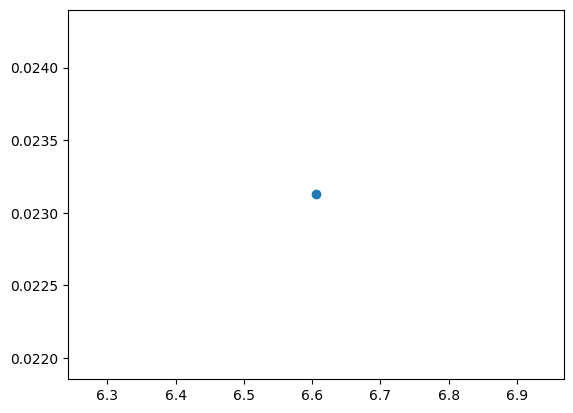

In [10]:
#stats

#spr is spike rate
all_spr = mean_spike_rate = np.sum(all_trials_sp, axis=(1,2))/(all_trials_sp.shape[1]*T*0.001)
mean_spr = np.mean(all_spr)
var_spr = np.var(all_spr)
FF = var_spr/mean_spr

plt.scatter(mean_spr, FF)

Text(0, 0.5, 'neuron index')

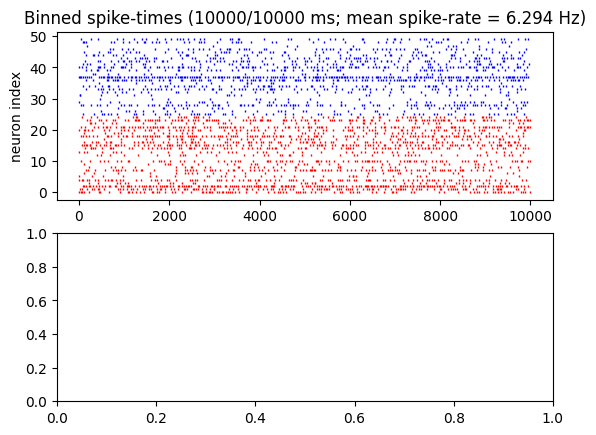

In [11]:
#plot binned spikes data
fig,ax = plt.subplots(2)

trial = 0
binned_spikes = all_trials_sp[trial]
markersize =1
plot_to_time = 10000 #ms
plot_to = int(plot_to_time/dt) #bins
ax[0].set_title('Binned spike-times ({}/{} ms; mean spike-rate = {} Hz)'.format(plot_to_time, T, all_spr[trial]))
nidx, tp = np.nonzero(binned_spikes[:, :plot_to]) #as arrays are too big and sparse for imshow visualization, extract non-zero element's indices
nidx_inh, tp_inh = nidx[nidx>=Ne_rec], tp[nidx>=Ne_rec] #divide into indices for inhibitory
nidx_exc, tp_exc = nidx[nidx<Ne_rec], tp[nidx<Ne_rec] #and exc
ax[0].plot(tp_inh*dt, nidx_inh,'|', markersize=markersize, color='blue')
ax[0].plot(tp_exc*dt, nidx_exc,'|', markersize=markersize, color='red')
ax[0].set_ylabel('neuron index')